             Datetime  MWh  Price_ore_kWh  Power_W  Q_m3s  P_MW
0 2024-01-01 00:00:00  0.0         33.227      0.0    0.0   0.0
1 2024-01-01 01:00:00  0.0         31.990      0.0    0.0   0.0
2 2024-01-01 02:00:00  0.0         29.967      0.0    0.0   0.0
3 2024-01-01 03:00:00  0.0         27.517      0.0    0.0   0.0
4 2024-01-01 04:00:00  0.0         26.988      0.0    0.0   0.0
=== NØKKELTALL CASE 2 - VIRKNINGSGRADSANALYSE ===
Total energi i drift: 171727.6 MWh
Gjennomsnittlig virkningsgrad i drift: 72.60 %
Energivektet virkningsgrad: 84.79 %
Timer med høy virkningsgrad: 2412
Andel driftstimer med høy virkningsgrad: 63.2 %
Andel energi produsert med høy virkningsgrad: 82.1 %

Fordeling etter virkningsgrad:
eta_kategori
Høy virkningsgrad        2412
Lav virkningsgrad         873
Middels virkningsgrad     531
Name: count, dtype: int64
Beste modellert virkningsgrad: 92.00 %

=== TAPT ENERGI PGA. LAV VIRKNINGSGRAD ===
Faktisk energi: 171727.6 MWh
Teoretisk energi ved beste virkningsgrad

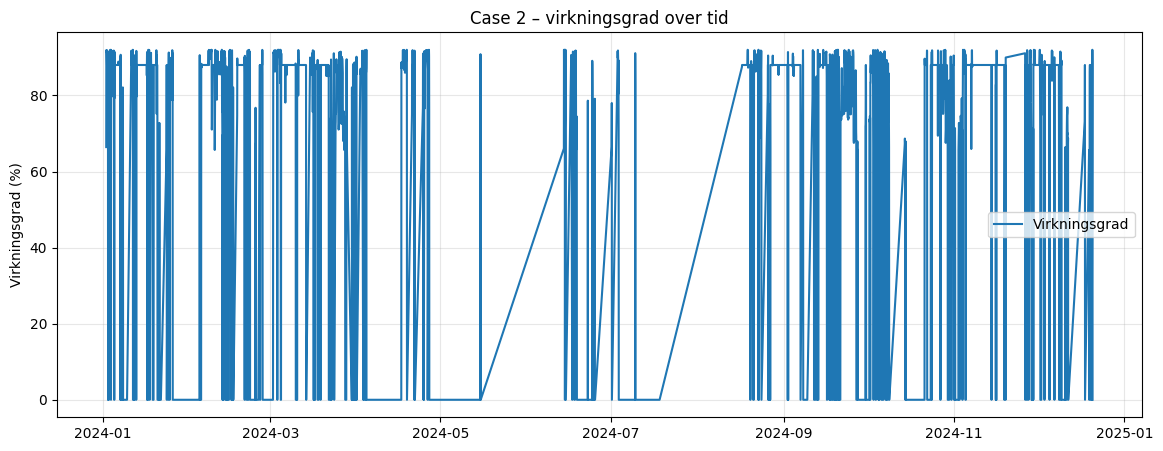

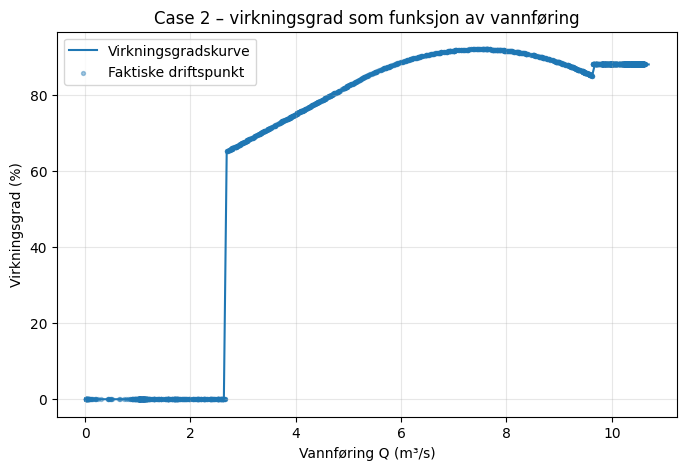

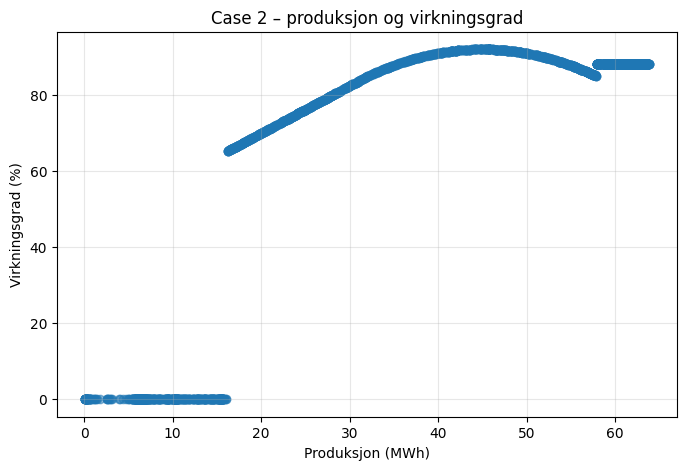

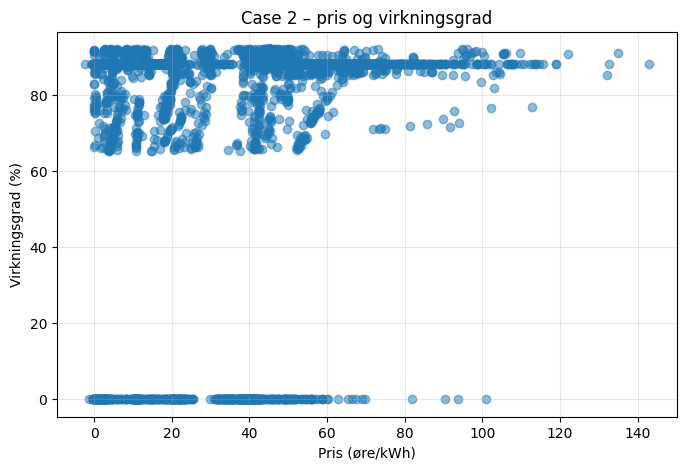

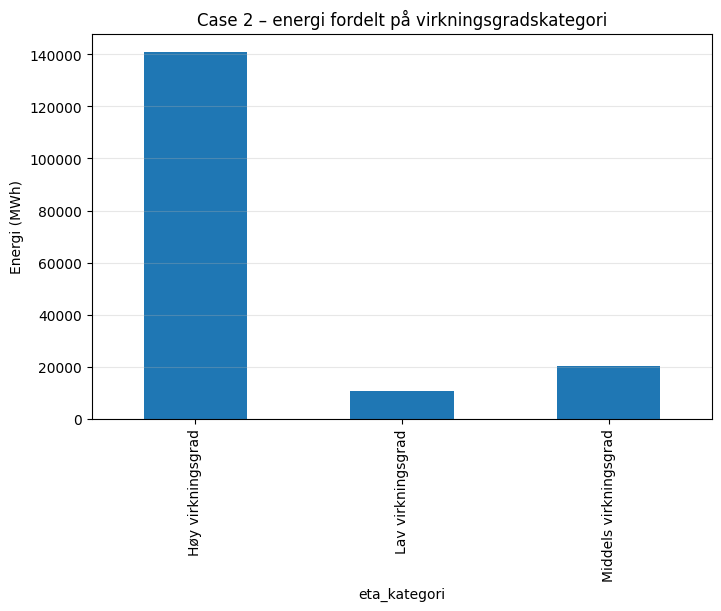

In [ ]:
# CASE 2 - VIRKNINGSGRADSANALYSE AV FAKTISK DRIFT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Sildvik_Produksjon_Pris_2024 (1).xlsx", engine="openpyxl")

df["Datetime"] = pd.to_datetime(df["Datetime"])
df["MWh"] = pd.to_numeric(df["MWh"], errors="coerce")
df["Price_ore_kWh"] = pd.to_numeric(df["Price_ore_kWh"], errors="coerce")

df = df.dropna().copy()

# Effekt
df["P_MW"] = df["MWh"]

# Vannføring
rho = 1000
g = 9.81
H = 680
eta = 0.90

df["Power_W"] = df["P_MW"] * 1e6
df["Q_m3s"] = df["Power_W"] / (eta * rho * g * H)

print(df.head())

df["Datetime"] = pd.to_datetime(df["Datetime"])
df["MWh"] = pd.to_numeric(df["MWh"], errors="coerce")
df["Price_ore_kWh"] = pd.to_numeric(df["Price_ore_kWh"], errors="coerce")

# Fysiske parametere

rho = 1000
g = 9.81
H_brutto = 680
Q_max = 10.7

# Falltap
k_loss = 5.2 / (11.0**2)

def h_loss(Q):
    return k_loss * Q**2

def H_netto(Q):
    return H_brutto - h_loss(Q)

# Virkningsgradskurve

def eta_turbin(Q):
    q_rel = Q / Q_max
    
    if q_rel <= 0:
        return 0.0
    elif q_rel < 0.25:
        return 0.0
    elif q_rel < 0.50:
        return 0.65 + (q_rel - 0.25) * (0.85 - 0.65) / 0.25
    elif q_rel < 0.90:
        return 0.85 + 0.07 * (1 - ((q_rel - 0.70) / 0.20)**2)
    elif q_rel <= 1.00:
        return 0.88
    else:
        return 0.0

# Beregn virkningsgrad for faktisk drift

df_case2 = df.copy()

df_case2["H_netto_m"] = df_case2["Q_m3s"].apply(H_netto)
df_case2["eta_model"] = df_case2["Q_m3s"].apply(eta_turbin)

# Relativ vannføring
df_case2["q_rel"] = df_case2["Q_m3s"] / Q_max

# Kun timer med produksjon
drift = df_case2[df_case2["MWh"] > 0].copy()


def eta_category(eta):
    if eta >= 0.88:
        return "Høy virkningsgrad"
    elif eta >= 0.75:
        return "Middels virkningsgrad"
    else:
        return "Lav virkningsgrad"

drift["eta_kategori"] = drift["eta_model"].apply(eta_category)

# Nøkkeltall for virkningsgradsanalyse

total_energy = drift["MWh"].sum()
avg_eta = drift["eta_model"].mean()
weighted_eta = (drift["eta_model"] * drift["MWh"]).sum() / drift["MWh"].sum()

hours_high_eta = (drift["eta_model"] >= 0.88).sum()
share_high_eta = hours_high_eta / len(drift) * 100

energy_high_eta = drift.loc[drift["eta_model"] >= 0.88, "MWh"].sum()
share_energy_high_eta = energy_high_eta / total_energy * 100

print("=== NØKKELTALL CASE 2 - VIRKNINGSGRADSANALYSE ===")
print(f"Total energi i drift: {total_energy:.1f} MWh")
print(f"Gjennomsnittlig virkningsgrad i drift: {avg_eta*100:.2f} %")
print(f"Energivektet virkningsgrad: {weighted_eta*100:.2f} %")
print(f"Timer med høy virkningsgrad: {hours_high_eta}")
print(f"Andel driftstimer med høy virkningsgrad: {share_high_eta:.1f} %")
print(f"Andel energi produsert med høy virkningsgrad: {share_energy_high_eta:.1f} %")

print("\nFordeling etter virkningsgrad:")
print(drift["eta_kategori"].value_counts())

# Tap i forhold til beste virkningsgrad

# Finner beste virkningsgrad i modellen
Q_test = np.linspace(0, Q_max, 500)
eta_test = np.array([eta_turbin(Q) for Q in Q_test])
eta_best = eta_test.max()

print(f"Beste modellert virkningsgrad: {eta_best*100:.2f} %")

# Hydraulisk effekt tilgjengelig ved faktisk vannføring
drift["P_hyd_MW"] = (
    rho * g * drift["Q_m3s"] * drift["H_netto_m"] / 1e6
)

# Faktisk modellert effekt med aktuell virkningsgrad
drift["P_model_MW"] = drift["P_hyd_MW"] * drift["eta_model"]

# Teoretisk effekt hvis samme vannmengde ble kjørt med beste virkningsgrad
drift["P_best_eta_MW"] = drift["P_hyd_MW"] * eta_best

# Tapt energi per time
drift["Lost_energy_MWh"] = drift["P_best_eta_MW"] - drift["P_model_MW"]
drift["Lost_energy_MWh"] = drift["Lost_energy_MWh"].clip(lower=0)

# Nøkkeltall
total_lost_energy = drift["Lost_energy_MWh"].sum()
actual_energy = drift["MWh"].sum()
potential_energy = actual_energy + total_lost_energy

print("\n=== TAPT ENERGI PGA. LAV VIRKNINGSGRAD ===")
print(f"Faktisk energi: {actual_energy:.1f} MWh")
print(f"Teoretisk energi ved beste virkningsgrad: {potential_energy:.1f} MWh")
print(f"Tapt energi pga. lavere virkningsgrad: {total_lost_energy:.1f} MWh")
print(f"Andel tapt energi: {total_lost_energy / potential_energy * 100:.2f} %")

# PLOTS CASE 2 - VIRKNINGSGRAD

plt.figure(figsize=(14,5))
plt.plot(drift["Datetime"], drift["eta_model"] * 100, label="Virkningsgrad")
plt.title("Case 2 - virkningsgrad over tid")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot 2: Virkningsgrad som funksjon av vannføring

Q_plot = np.linspace(0, Q_max, 200)
eta_plot = [eta_turbin(Q) for Q in Q_plot]

plt.figure(figsize=(8,5))
plt.plot(Q_plot, np.array(eta_plot) * 100, label="Virkningsgradskurve")
plt.scatter(drift["Q_m3s"], drift["eta_model"] * 100, s=8, alpha=0.4, label="Faktiske driftspunkt")
plt.title("Case 2 - virkningsgrad som funksjon av vannføring")
plt.xlabel("Vannføring Q (m³/s)")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot 3: Produksjon vs virkningsgrad

plt.figure(figsize=(8,5))
plt.scatter(drift["MWh"], drift["eta_model"] * 100, alpha=0.5)
plt.title("Case 2 - produksjon og virkningsgrad")
plt.xlabel("Produksjon (MWh)")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.show()

# Plot 4: Pris vs virkningsgrad

plt.figure(figsize=(8,5))
plt.scatter(drift["Price_ore_kWh"], drift["eta_model"] * 100, alpha=0.5)
plt.title("Case 2 - pris og virkningsgrad")
plt.xlabel("Pris (øre/kWh)")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.show()

# Plot 5: Energi fordelt på virkningsgradskategorier

energy_by_eta = drift.groupby("eta_kategori")["MWh"].sum()

plt.figure(figsize=(8,5))
energy_by_eta.plot(kind="bar")
plt.title("Case 2 - energi fordelt på virkningsgradskategori")
plt.ylabel("Energi (MWh)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [ ]:
# Svakheter med denne modellen:

# I praksis påvirkes total virkningsgrad også av:
#generator, transformator, hjelpesystemer, delasttap

# Virkningsgradskurven er forenklet og basert på generelle antakelser:
# Det betyr: ikke basert på faktisk hill chart, ikke levert av turbineleverandør, ikke testdata fra anlegget 

# Konstant brutto fallhøyde

# Forenklet falltap

# Modellen antar at alle nulltimer er økonomiske valg. Tar ikke hensyn til tekniske begrensninger, vedlikehold, eller andre faktorer som kan påvirke driftsbeslutninger.


# Kan forbedres ved å:
# Inkludere flere faktorer i virkningsgradskurven, som generator og transformator
# Bruke faktisk hill chart eller testdata for å kalibrere modellen
# Inkludere variasjoner i brutto fallhøyde gjennom en graf etc
